In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

In [115]:
# Load your fully feature-engineered dataset

# df = pd.read_csv("feature_engineering/data_with_new_features.csv")
# participant_col_name = 'participant'

df = pd.read_csv("../data_cleaning/data/imputed_data.csv")
participant_col_name = 'person'


In [116]:
# Exclude non-numeric columns
exclude_cols = [participant_col_name, 'timestamp', 'genre']
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

# Global normalization
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Encode other categorical columns (if any, excluding participant/timestamp/genre)
categorical_cols = df.select_dtypes(include=['object']).columns.difference([participant_col_name, 'timestamp', 'genre'])


for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode the target variable 'genre'
genre_label_encoder = LabelEncoder()
df['genre_encoded'] = genre_label_encoder.fit_transform(df['genre'])

# Split by participant
train_df = df[df[participant_col_name].isin(['kenji', 'aimen'])].copy()
test_df = df[df[participant_col_name] == 'clara'].copy()

# Split Clara's data into validation (20%) and test (80%) stratified on genre
val_df, final_test_df = train_test_split(
    test_df,
    test_size=0.8,
    stratify=test_df['genre_encoded'],
    random_state=42
)


# define features and labels
X_train = train_df[numeric_cols]
y_train = train_df['genre_encoded']

X_val = val_df[numeric_cols]
y_val = val_df['genre_encoded']

X_test = final_test_df[numeric_cols]
y_test = final_test_df['genre_encoded']

In [117]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 20 features using f_classif
k = 20
selector = SelectKBest(score_func=f_classif, k=k)

# Fit only on training data
X_train_selected = selector.fit_transform(X_train, y_train)

# Apply same transformation to val and test
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# Get names of selected features (optional, for inspection)
selected_feature_names = X_train.columns[selector.get_support()].tolist()
print(f"Top {k} selected features:\n", selected_feature_names)


Top 20 selected features:
 ['heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm', 'iris_diameter_mm', 'pupil_iris_ratio']


In [118]:
def create_model(input_dim):
    model = Sequential([
        Dense(64, input_dim=input_dim, kernel_regularizer=l1_l2(l2=1e-3)),
        LeakyReLU(alpha=0.0005),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(32, kernel_regularizer=l1_l2(l2=1e-3)),
        LeakyReLU(alpha=0.0005),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(3, activation='softmax')
    ])
    
    # Compile and train
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    return model

model = create_model(X_train_selected.shape[1])

In [119]:
from tensorflow.keras.utils import to_categorical

# One-hot encode the genre labels
y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)


In [120]:

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7)
]

history = model.fit(
    X_train_selected, y_train_cat,
    validation_data=(X_val_selected, y_val_cat),
    epochs=50,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step - accuracy: 0.5332 - loss: 1.1404 - precision: 0.5575 - recall: 0.4730 - val_accuracy: 0.4338 - val_loss: 1.3581 - val_precision: 0.4410 - val_recall: 0.4180 - learning_rate: 0.0010
Epoch 2/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step - accuracy: 0.7407 - loss: 0.6599 - precision: 0.7657 - recall: 0.7034 - val_accuracy: 0.4702 - val_loss: 1.3824 - val_precision: 0.4878 - val_recall: 0.4629 - learning_rate: 0.0010
Epoch 3/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - accuracy: 0.7694 - loss: 0.6107 - precision: 0.7870 - recall: 0.7432 - val_accuracy: 0.4897 - val_loss: 1.2405 - val_precision: 0.4931 - val_recall: 0.4775 - learning_rate: 0.0010
Epoch 4/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.7901 - loss: 0.5495 - precision: 0.8034 - recall: 0.7684 - val_accuracy: 0.5006 - val_loss: 1.0467 - val_precision: 0.5064 - val_recall: 0.4787 - learning_rate: 0.0010
Epoch 5/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - 

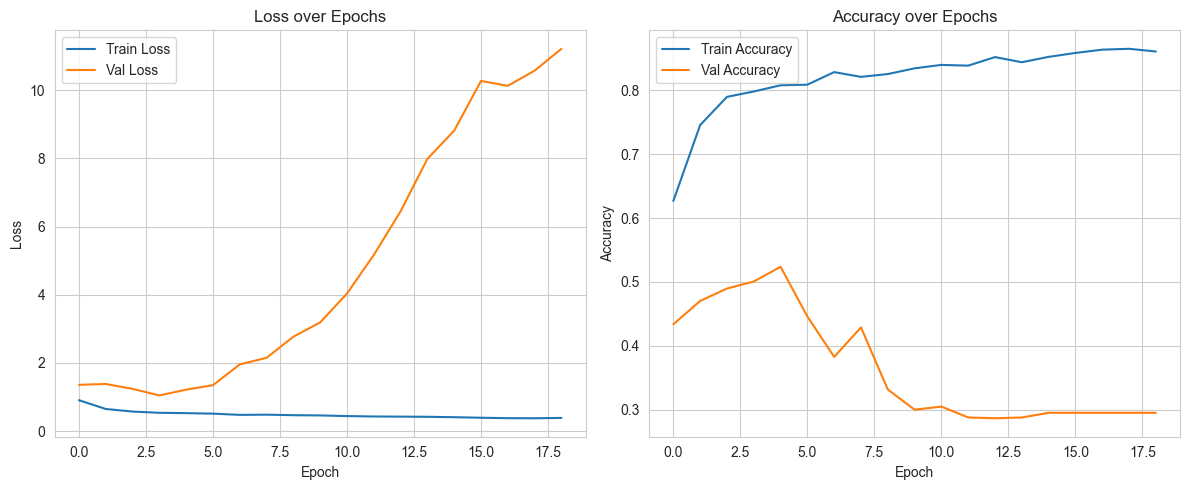

In [121]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [122]:
# Predict class probabilities
y_test_probs = model.predict(X_test_selected)

# Convert to predicted class labels
y_test_preds = np.argmax(y_test_probs, axis=1)


103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step


In [123]:
from sklearn.metrics import classification_report

print("Test Classification Report:\n")
print(classification_report(y_test, y_test_preds, target_names=genre_label_encoder.classes_))


Test Classification Report:

              precision    recall  f1-score   support

      comedy       0.15      0.11      0.13      1072
 documentary       0.48      0.72      0.58      1248
      horror       0.97      0.60      0.74       973

    accuracy                           0.49      3293
   macro avg       0.53      0.48      0.48      3293
weighted avg       0.52      0.49      0.48      3293



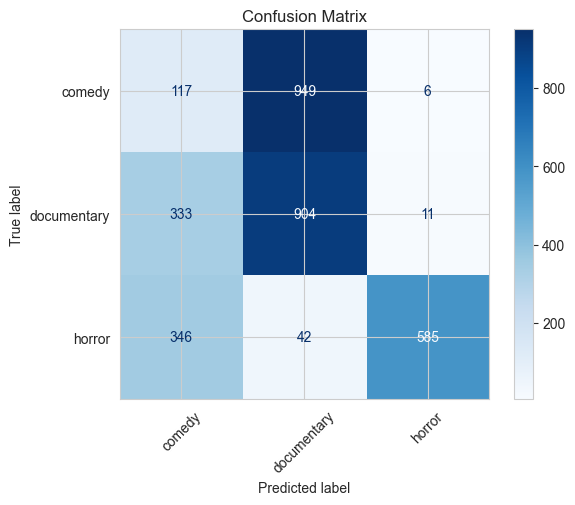

In [124]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genre_label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
